In [20]:
# ─── Version checks ─────────────────────────────────────────────────────────────
import sys

import torch
import torch_geometric

# ─── PyG & PyTorch modules ─────────────────────────────────────────────────────
from torch import nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader, LinkNeighborLoader
from torch_geometric.nn import GCNConv, GAE, HeteroConv
from torch_geometric.utils import train_test_split_edges
import torch.nn.functional as F
from torch_geometric.data import Data as HomoData
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import SAGEConv
from torch_geometric.nn import MetaPath2Vec
from torch_geometric.transforms import ToUndirected



# ─── Data handling & ML utilities ───────────────────────────────────────────────
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import defaultdict, Counter
import re

from sklearn.cluster import KMeans
from utils import evaluate_clustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix


import networkx as nx
from node2vec import Node2Vec as PureNode2Vec










# ─── File paths ────────────────────────────────────────────────────────────────

FEATURE_DIR   =  "features"
WEEKLY_DIR         = "weekly_features"

EDGE_MASTER_PATH   = "edges_master2.csv"
SCENARIO_FPATH     = os.path.join(
    WEEKLY_DIR,
    "CO2_Humidity_temp__floors1_2_3_4_5_6_7__weekly.csv"
)
MAPPING_FPATH      = os.path.join(
    FEATURE_DIR,
    "temp_humidity_co2_floor_allfloors__fullday.pkl"
)

# ─── Load data ─────────────────────────────────────────────────────────────────
master_edges = pd.read_csv(EDGE_MASTER_PATH)
scenario_df  = pd.read_csv(SCENARIO_FPATH)  # load as needed


In [21]:
def build_hetero_subgraph(
    scenario_csv: str,
    master_edges: pd.DataFrame
) -> HeteroData:
    """
    Build a per‐scenario HeteroData subgraph using only:
      • master_edges.relation ∈ {device_room, device_property, room_floor}
      • scenario CSV’s device list
      • inclusion flags from the scenario name

    Assumes master_edges has columns:
      source, target, relation, src_local, tgt_local
    where src_local/tgt_local = URI suffix (device/room/floor/property).
    """

    # 1) Parse scenario key to decide which edge types to include
    fname = os.path.basename(scenario_csv)
    key = fname.replace("__weekly.csv", "")
    # number of properties = tokens before "_floors"
    n_props  = len(key.split("_floors")[0].split("_"))
    # number of floors = tokens after "floors"
    m_f = re.search(r"_floors(.+)$", key)
    n_floors = len(m_f.group(1).split("_")) if m_f else 1

    include_dp = (n_props  > 1)     # at least two properties
    include_rf = (n_floors > 1)     # multi‐floor
    # device–room only if some room has >1 device
    # we’ll compute that below

    ''' # 2) Load sensor features & build device set
    feat_df = pd.read_csv(scenario_csv, index_col="device")

    numeric_cols = feat_df.select_dtypes(include='number').columns.tolist()
    def _local(u): return u.split("/")[-1] if isinstance(u, str) else u
    feat_df.index = feat_df.index.map(_local)
    feat_df = feat_df[numeric_cols]'''
    # 2) Load sensor features & build device set
    feat_df = pd.read_csv(scenario_csv, index_col="device")

    # ── NEW ── collapse to unique devices ────────────────────────────────
     # 1) Helper to strip URIs to local IDs
    def _local(u):
        if isinstance(u, str):
            base = u.split("/")[-1]
            return base.split("__")[0]
        return u

    # 2) Load and collapse features to unique devices
    feat_df = pd.read_csv(scenario_csv, index_col="device")
    # Strip URIs → local IDs → drop any "__…" suffix
    feat_df.index = feat_df.index.map(_local)
    # Collapse to one row per device (we only need the shape and node IDs)
    feat_df = feat_df.groupby(feat_df.index).first()

    # 3) Keep only numeric columns as node features
    numeric_cols = feat_df.select_dtypes(include='number').columns.tolist()
    feat_df      = feat_df[numeric_cols]
    devices = set(feat_df.index)

    # 3) Ensure local IDs on master_edges
    if 'src_local' not in master_edges:
        master_edges['src_local'] = master_edges['source'].map(_local)
        master_edges['tgt_local'] = master_edges['target'].map(_local)

    # 4) Filter & count device→room edges to decide include_dr
    dr = master_edges.query("relation=='device_room'")
    # only keep edges touching our devices
    dr = dr[ dr.src_local.isin(devices) | dr.tgt_local.isin(devices) ]
    # count sensors per room
    room_counts = Counter()
    for _, row in dr.iterrows():
        d, r = (row.src_local, row.tgt_local) if row.relation=='device_room' and row.src_local in devices else (row.tgt_local, row.src_local)
        room_counts[r] += 1
    include_dr = max(room_counts.values(), default=0) > 1

    print(f"[{key}] props={n_props}, floors={n_floors}, "
          f"devices={len(devices)} => dr={include_dr}, dp={include_dp}, rf={include_rf}")

    # 5) Build index maps
    dev2idx  = {d:i for i,d in enumerate(sorted(devices))}
    room2idx = {}
    prop2idx = {}
    floor2idx= {}

    if include_dr:
        rooms = set(dr['src_local'].where(dr.src_local.map(lambda x: x not in devices), dr.tgt_local))
        room2idx = {r:i for i,r in enumerate(sorted(rooms))}
    if include_dp:
        dp = master_edges.query("relation=='device_property'")
        dp = dp[ dp.src_local.isin(devices) | dp.tgt_local.isin(devices) ]
        props = set(dp['src_local'].where(dp.src_local.map(lambda x: x not in devices), dp.tgt_local))
        prop2idx = {p:i for i,p in enumerate(sorted(props))}
    if include_rf:
        rf = master_edges.query("relation=='room_floor'")
        floors = set(rf['src_local'].where(rf.src_local.map(lambda x: x not in rooms), rf.tgt_local))
        floor2idx = {f:i for i,f in enumerate(sorted(floors))}
    # feat_df.index already mapped with _local
    devices = list(sorted(devices))

    # All known IDs in master_edges
    known_ids = set(master_edges['src_local']) | set(master_edges['tgt_local'])

    # Split into matched vs unmatched
    matched   = [d for d in devices if d in known_ids]
    unmatched = [d for d in devices if d not in known_ids]

    print(f"{len(matched)} matched device IDs (sample 10): {matched[:10]}")
    print(f"{len(unmatched)} unmatched device IDs (sample 10): {unmatched[:10]}")
        # feat_df indexed by device (with duplicates per property)
    feat_unique = feat_df.groupby(feat_df.index).mean()
    # Build dev2idx from feat_unique.index

    # 6) Collect edges and convert to index pairs
    H = HeteroData()
    H['sensor'].x = torch.tensor(feat_unique.values, dtype=torch.float)
    
    def _add(relation, src_map, tgt_map, src_type, dst_type):
        df = master_edges.query(f"relation=='{relation}'")
        rows = []
        for _, row in df.iterrows():
            a, b = row.src_local, row.tgt_local
            # decide which end is device vs room/prop/floor
            if src_map is dev2idx and a in dev2idx and b in tgt_map:
                rows.append((dev2idx[a], tgt_map[b]))
            elif src_map is dev2idx and b in dev2idx and a in tgt_map:
                rows.append((dev2idx[b], tgt_map[a]))
            elif src_map is room2idx and a in room2idx and b in floor2idx:
                rows.append((room2idx[a], floor2idx[b]))
            elif src_map is room2idx and b in room2idx and a in floor2idx:
                rows.append((room2idx[b], floor2idx[a]))
        if rows:
            H[src_type, 'to', dst_type].edge_index = torch.tensor(rows, dtype=torch.long).t().contiguous()

    if include_dr:
        H['room'].x = torch.zeros((len(room2idx),1))
        _add('device_room', dev2idx, room2idx, 'sensor', 'room')
    if include_dp:
        H['property'].x = torch.zeros((len(prop2idx),1))
        _add('device_property', dev2idx, prop2idx, 'sensor', 'property')
    if include_rf:
        H['floor'].x = torch.zeros((len(floor2idx),1))
        _add('room_floor', room2idx, floor2idx, 'room', 'floor')

    return H

def visualize_clusters(
    name: str,
    X: np.ndarray,
    true_labels: np.ndarray,
    cluster_labels: np.ndarray,
    k_ground: int,
    k_range=range(2, 11)
):
    """
    Produces:
      1) 2D embedding scatter (PCA), colored by true_labels and cluster_labels
      2) Silhouette vs k lineplot with ground-truth marker
      3) Confusion‐matrix heatmap of cluster_labels vs true_labels
      4) Bar chart of per-cluster sizes
    """
    # 1) PCA scatter
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # True labels
    scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='tab10', alpha=0.7)
    ax1.set_title(f"{name}: PCA colored by True Labels")
    legend1 = ax1.legend(*scatter.legend_elements(), title="True")
    ax1.add_artist(legend1)

    # Cluster labels
    scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
    ax2.set_title(f"{name}: PCA colored by Cluster Labels")
    legend2 = ax2.legend(*scatter2.legend_elements(), title="Cluster")
    ax2.add_artist(legend2)

    # 2) Silhouette vs k
    sil_scores = []
    for k in k_range:
        labels_k = KMeans(n_clusters=k, random_state=42).fit_predict(X)
        sil_scores.append(silhouette_score(X, labels_k))
    ax3.plot(list(k_range), sil_scores, marker='o')
    ax3.axvline(k_ground, color='r', linestyle='--', label=f"True k={k_ground}")
    ax3.set_xlabel("k")
    ax3.set_ylabel("Silhouette Score")
    ax3.set_title(f"{name}: Silhouette vs k")
    ax3.legend()

    # 3) Confusion matrix
    cm = confusion_matrix(true_labels, cluster_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax4)
    ax4.set_title(f"{name}: Confusion Matrix")
    ax4.set_xlabel("Predicted")
    ax4.set_ylabel("True")

    # 4) Cluster size bar chart below
    fig2, ax5 = plt.subplots(figsize=(6, 4))
    counts = np.bincount(cluster_labels)
    ax5.bar(range(len(counts)), counts, color='skyblue')
    ax5.axhline(len(cluster_labels) / k_ground, color='r', linestyle='--', label='Avg size')
    ax5.set_xlabel("Cluster ID")
    ax5.set_ylabel("Count")
    ax5.set_title(f"{name}: Cluster Sizes (k={len(counts)})")
    ax5.legend()

    plt.tight_layout()
    plt.show()



def build_hetero_subgraph2(
    scenario_csv: str,
    master_edges: pd.DataFrame
) -> HeteroData:
    """
    Build a per‐scenario HeteroData subgraph using only:
      • master_edges.relation ∈ {device_room, device_property, room_floor}
      • scenario CSV’s device list (collapsed to unique devices)
      • inclusion flags from the scenario name
    """

    # ─── Helper to strip URIs to local IDs ─────────────────────────────────
    def _local(u):
        if isinstance(u, str):
            return u.split("/")[-1].split("__")[0]
        return u

    # ─── 1) Parse scenario key to decide edge types ────────────────────────
    fname      = os.path.basename(scenario_csv)
    key        = fname.replace("__weekly.csv", "")
    n_props    = len(key.split("_floors")[0].split("_"))
    m_f        = re.search(r"_floors(.+)$", key)
    n_floors   = len(m_f.group(1).split("_")) if m_f else 1
    include_dp = (n_props  > 1)
    include_rf = (n_floors > 1)

    # ─── 2) Load & collapse to unique devices ─────────────────────────────
    df = pd.read_csv(scenario_csv)
    df['device'] = df['device'].map(_local)
    numeric_cols = df.select_dtypes(include='number').columns
    feat_unique  = df.groupby('device', as_index=True)[numeric_cols].mean()

    # ─── 3) Build device index map & node features ────────────────────────
    devices = sorted(feat_unique.index.tolist())
    dev2idx = {d: i for i, d in enumerate(devices)}

    H = HeteroData()
    H['sensor'].x = torch.tensor(feat_unique.values, dtype=torch.float)

    # ─── 4) Map master_edges URIs to local IDs ────────────────────────────
    if 'src_local' not in master_edges:
        master_edges['src_local'] = master_edges['source'].map(_local)
        master_edges['tgt_local'] = master_edges['target'].map(_local)

    # ─── 5) Determine include_dr by counting sensors per room ─────────────
    dr = master_edges.query("relation=='device_room'")
    dr = dr[dr.src_local.isin(devices) | dr.tgt_local.isin(devices)]
    room_counts = Counter()
    for _, row in dr.iterrows():
        # whichever side is the device → the other side is the room
        if row.src_local in dev2idx:
            room = row.tgt_local
        else:
            room = row.src_local
        room_counts[room] += 1
    include_dr = max(room_counts.values(), default=0) > 1

    # ─── 6) Build index maps for room/property/floor ─────────────────────
    room2idx = {}
    prop2idx = {}
    floor2idx= {}

    if include_dr:
        # collect all rooms that appear in dr and are not device IDs
        rooms = {r for _, row in dr.iterrows()
                   for r in (row.src_local, row.tgt_local)
                   if r not in dev2idx}
        room2idx = {r: i for i, r in enumerate(sorted(rooms))}

    if include_dp:
        dp = master_edges.query("relation=='device_property'")
        dp = dp[dp.src_local.isin(devices) | dp.tgt_local.isin(devices)]
        props = {p for _, row in dp.iterrows()
                    for p in (row.src_local, row.tgt_local)
                    if p not in dev2idx}
        prop2idx = {p: i for i, p in enumerate(sorted(props))}

    if include_rf:
        rf = master_edges.query("relation=='room_floor'")
        # only keep those touching our selected rooms
        rf = rf[rf.src_local.isin(room2idx) | rf.tgt_local.isin(room2idx)]
        floors = {f for _, row in rf.iterrows()
                     for f in (row.src_local, row.tgt_local)
                     if f not in room2idx}
        floor2idx = {f: i for i, f in enumerate(sorted(floors))}

    # ─── 7) Helper to add edges ────────────────────────────────────────────
    def _add_edges(relation, src_map, tgt_map, src_type, dst_type):
        edges = []
        for _, row in master_edges.query(f"relation=='{relation}'").iterrows():
            a, b = row.src_local, row.tgt_local
            if a in src_map and b in tgt_map:
                edges.append((src_map[a], tgt_map[b]))
            elif b in src_map and a in tgt_map:
                edges.append((src_map[b], tgt_map[a]))
        if edges:
            H[(src_type, 'to', dst_type)].edge_index = \
                torch.tensor(edges, dtype=torch.long).t().contiguous()

    # ─── 8) Populate HeteroData ───────────────────────────────────────────
    if include_dr:
        H['room'].x = torch.zeros((len(room2idx), 1))
        _add_edges('device_room',    dev2idx, room2idx, 'sensor',   'room')
    if include_dp:
        H['property'].x = torch.zeros((len(prop2idx), 1))
        _add_edges('device_property',dev2idx, prop2idx, 'sensor',   'property')
    if include_rf:
        H['floor'].x = torch.zeros((len(floor2idx), 1))
        _add_edges('room_floor',     room2idx, floor2idx,'room',     'floor')

    print(f"[{key}] devices={len(devices)}, dr={include_dr}, dp={include_dp}, rf={include_rf}")
    return H


In [22]:


# Load
dff = pd.read_pickle(MAPPING_FPATH)
df  = pd.read_csv(SCENARIO_FPATH)

# Features
feature_cols = [c for c in df.columns if c not in ['device','property']]
stats_feats  = df[feature_cols].values

# Labels
labels_df       = df.merge(dff[['device','floor']].drop_duplicates(), on='device', how='left')
floor_labels    = labels_df['floor'].astype(int).values
property_labels = df['property'].astype('category').cat.codes.values

# Cluster counts
n_floors     = len(np.unique(floor_labels))
n_properties = len(np.unique(property_labels))


In [23]:
import numpy as np
from collections import defaultdict

def stability_evaluation(features, true_labels, proxy_classes, n_clusters, trials=10):
    all_metrics = defaultdict(list)
    for seed in range(trials):
        preds = KMeans(n_clusters=n_clusters, random_state=seed).fit_predict(features)
        res = evaluate_clustering(
            features=features,
            pred_labels=preds,
            true_labels=true_labels,
            proxy_classes=proxy_classes
        )
        for metric, val in res.items():
            all_metrics[metric].append(val)

    # aggregate
    aggregated = {}
    for metric, vals in all_metrics.items():
        vals = np.array(vals)
        if vals.ndim == 1:  # scalar metrics
            aggregated[metric] = (vals.mean(), vals.std())
        else:  # per-class arrays
            aggregated[metric] = (vals.mean(axis=0), vals.std(axis=0))
    return aggregated
from sklearn.preprocessing import StandardScaler

# Scale stats and embeddings independently
stats_scaled = StandardScaler().fit_transform(stats_feats)


# Example for floors
stats_floor_stability = stability_evaluation(
    stats_scaled, floor_labels, n_floors, n_clusters=n_floors, trials=10
)
stats_property_stability = stability_evaluation(
    stats_scaled, property_labels, n_properties, n_clusters=n_properties, trials=10
)

/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_pr

In [24]:
# Convert to DataFrame for saving
def stability_dict_to_df(stability_dict):
    rows = []
    for metric, (mean_val, std_val) in stability_dict.items():
        rows.append({
            'metric': metric,
            'mean': mean_val,
            'std': std_val
        })
    return pd.DataFrame(rows).set_index('metric')

df_floor = stability_dict_to_df(stats_floor_stability)
df_prop  = stability_dict_to_df(stats_property_stability)

# Save to CSV
df_floor.to_csv('stats_floor_stability.csv')
df_prop.to_csv('stats_property_stability.csv')


In [25]:
# ─── Stats-only clustering & evaluation ──────────────────────────────────────
# Floors
pred_floor    = KMeans(n_clusters=n_floors, random_state=42).fit_predict(stats_feats)
results_floor = evaluate_clustering(
    features=stats_feats,
    pred_labels=pred_floor,
    true_labels=floor_labels,
    proxy_classes=n_floors
)

# Properties
pred_prop     = KMeans(n_clusters=n_properties, random_state=42).fit_predict(stats_feats)
results_prop  = evaluate_clustering(
    features=stats_feats,
    pred_labels=pred_prop,
    true_labels=property_labels,
    proxy_classes=n_properties
)

# ─── Print summaries ─────────────────────────────────────────────────────────
print("\nStats-only → Floor proxy metrics:")
for metric, val in results_floor.items():
    print(f"  {metric}: {val}")
print ("K clusters:", n_floors)

print("\nStats-only → Property proxy metrics:")
for metric, val in results_prop.items():
    print(f"  {metric}: {val}")
print ("K clusters:", n_properties)



Stats-only → Floor proxy metrics:
  silhouette: 0.7521661800905647
  calinski_harabasz: 7363.326433227016
  davies_bouldin: 1.3191598409608376
  ARI: -0.010467957177834847
  NMI: 0.048153987951827154
  precision: [0.         0.22222222 0.         0.         0.17948718 0.
 0.11111111]
  recall: [0.         0.19354839 0.         0.         0.04895105 0.
 0.01470588]
  f1: [0.         0.20689655 0.         0.         0.07692308 0.
 0.02597403]
  precision_macro: 0.0641025641025641
  recall_macro: 0.03215066480009554
  f1_macro: 0.03872420682765511
  confusion_matrix: [[  0   0   0   0   0   0   0]
 [ 99  30   3   8   8   2   5]
 [ 63  20   0   0   4   4   0]
 [100  32   0   0   9   7   1]
 [ 94  27   1   3   7   1  10]
 [ 27   0   0   0   1   0   0]
 [ 92  26   7   0   5   4   2]]
K clusters: 7

Stats-only → Property proxy metrics:
  silhouette: 0.7965349387446115
  calinski_harabasz: 9267.180298893969
  davies_bouldin: 1.026192927792346
  ARI: 0.47209166227536387
  NMI: 0.65001612521236

/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_pr

In [26]:
from sklearn.mixture import GaussianMixture

# ─── Stats-only GMM clustering & evaluation ────────────────────────────────
# Floors via GMM
gmm_floor = GaussianMixture(n_components=n_floors, covariance_type='full', random_state=42)
gmm_floor_labels = gmm_floor.fit_predict(stats_feats)
results_floor_gmm = evaluate_clustering(
    features=stats_feats,
    pred_labels=gmm_floor_labels,
    true_labels=floor_labels,
    proxy_classes=n_floors
)

# Properties via GMM
gmm_prop = GaussianMixture(n_components=n_properties, covariance_type='full', random_state=42)
gmm_prop_labels = gmm_prop.fit_predict(stats_feats)
results_prop_gmm = evaluate_clustering(
    features=stats_feats,
    pred_labels=gmm_prop_labels,
    true_labels=property_labels,
    proxy_classes=n_properties
)

# ─── Print GMM summaries ────────────────────────────────────────────────────
print("\nGMM stats-only → Floor proxy metrics:")
for metric, val in results_floor_gmm.items():
    print(f"  {metric}: {val}")
print("K clusters:", n_floors)

print("\nGMM stats-only → Property proxy metrics:")
for metric, val in results_prop_gmm.items():
    print(f"  {metric}: {val}")
print("K clusters:", n_properties)


/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_pr


GMM stats-only → Floor proxy metrics:
  silhouette: 0.7521661800905647
  calinski_harabasz: 7363.326433227016
  davies_bouldin: 1.3191598409608376
  ARI: -0.010467957177834847
  NMI: 0.048153987951827154
  precision: [0.         0.22222222 0.         0.         0.17948718 0.
 0.11111111]
  recall: [0.         0.19354839 0.         0.         0.04895105 0.
 0.01470588]
  f1: [0.         0.20689655 0.         0.         0.07692308 0.
 0.02597403]
  precision_macro: 0.0641025641025641
  recall_macro: 0.03215066480009554
  f1_macro: 0.03872420682765511
  confusion_matrix: [[  0   0   0   0   0   0   0]
 [ 99  30   3   8   8   2   5]
 [ 63  20   0   0   4   4   0]
 [100  32   0   0   9   7   1]
 [ 94  27   1   3   7   1  10]
 [ 27   0   0   0   1   0   0]
 [ 92  26   7   0   5   4   2]]
K clusters: 7

GMM stats-only → Property proxy metrics:
  silhouette: 0.8007342316941237
  calinski_harabasz: 9184.588298318167
  davies_bouldin: 1.060837500885497
  ARI: 0.477812337067592
  NMI: 0.65334653

In [27]:
# 2) Build the per‐scenario subgraph
hetero = build_hetero_subgraph(SCENARIO_FPATH, master_edges)
from utils import project_sensor_graph
# 2) Project to a homogeneous sensor–sensor graph (with floor edges)
include_floor = ('room', 'to', 'floor') in hetero.edge_types
homo = project_sensor_graph(hetero, include_floor_edges=include_floor)


[CO2_Humidity_temp__floors1_2_3_4_5_6_7] props=4, floors=7, devices=281 => dr=True, dp=True, rf=True
281 matched device IDs (sample 10): ['R5_1', 'R5_10', 'R5_100', 'R5_101', 'R5_102', 'R5_103', 'R5_104', 'R5_105', 'R5_106', 'R5_107']
0 unmatched device IDs (sample 10): []
> Projecting sensor graph: N_sensors=281, include_floor_edges=True
  → gathered 6320 undirected pairs
  → final edge count: 12640


In [28]:
# 3) Summarize edge counts
n_sr = hetero['sensor','to','room'].edge_index.size(1) if ('sensor','to','room') in hetero.edge_types else 0
n_sp = hetero['sensor','to','property'].edge_index.size(1) if ('sensor','to','property') in hetero.edge_types else 0
n_rf = hetero['room','to','floor'].edge_index.size(1) if include_floor else 0
n_homo = homo.edge_index.size(1)

print(f"\nEdge counts:")
print(f"  sensor→room:     {n_sr}")
print(f"  sensor→property: {n_sp}")
print(f"  room→floor:      {n_rf}")
print(f"  projected (homo):{n_homo}")



Edge counts:
  sensor→room:     281
  sensor→property: 894
  room→floor:      239
  projected (homo):12640


In [29]:
# 1) Build NetworkX graph from homo.edge_index
edge_ix = homo.edge_index.cpu().numpy()
G = nx.Graph()
G.add_nodes_from(range(stats_feats.shape[0]))
G.add_edges_from(list(zip(edge_ix[0], edge_ix[1])))

# 2) Run pure‐Python Node2Vec
n2v = PureNode2Vec(G, dimensions=64, walk_length=10, num_walks=20, workers=4)
nv_model = n2v.fit(window=5, min_count=1)

# 3) Extract embeddings: one vector per node in 0..N-1
nv_feats = np.vstack([nv_model.wv[str(n)] for n in range(stats_feats.shape[0])])

# 4) Node2Vec-only clustering & evaluation
pred_floor_nv = KMeans(n_clusters=n_floors, random_state=42).fit_predict(nv_feats)
res_floor_nv  = evaluate_clustering(nv_feats, pred_floor_nv, floor_labels,    n_floors)

pred_prop_nv  = KMeans(n_clusters=n_properties, random_state=42).fit_predict(nv_feats)
res_prop_nv   = evaluate_clustering(nv_feats, pred_prop_nv,  property_labels, n_properties)

# 5) Fusion: stats + Node2Vec
fusion_feats     = np.hstack([stats_feats, nv_feats])
pred_floor_f     = KMeans(n_clusters=n_floors, random_state=42).fit_predict(fusion_feats)
res_floor_f      = evaluate_clustering(fusion_feats, pred_floor_f, floor_labels,    n_floors)

pred_prop_f      = KMeans(n_clusters=n_properties, random_state=42).fit_predict(fusion_feats)
res_prop_f       = evaluate_clustering(fusion_feats, pred_prop_f,  property_labels, n_properties)

# 6) Print all results
print("Node2Vec → Floor:",      res_floor_nv)
print("Stats+Node2Vec → Floor:", res_floor_f)
print("Node2Vec → Property:",   res_prop_nv)
print("Stats+Node2Vec → Property:", res_prop_f)


Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 92.32it/s]


Node2Vec → Floor: {'silhouette': 0.9376888871192932, 'calinski_harabasz': 2201.4171959466803, 'davies_bouldin': 0.39715760491042895, 'ARI': -0.003237578595280806, 'NMI': 0.031736217741622316, 'precision': array([0.        , 0.18693694, 0.109375  , 0.23728814, 0.11764706,
       0.        , 0.15151515]), 'recall': array([0.        , 0.53548387, 0.07692308, 0.09395973, 0.04195804,
       0.        , 0.03676471]), 'f1': array([0.        , 0.27712855, 0.09032258, 0.13461538, 0.06185567,
       0.        , 0.0591716 ]), 'precision_macro': 0.10034528535860478, 'recall_macro': 0.09813617840935475, 'f1_macro': 0.0778867225720092, 'confusion_matrix': array([[  0,   0,   0,   0,   0,   0,   0],
       [  7,  83,  21,  11,  14,  11,   8],
       [  5,  40,   7,  13,   7,   9,  10],
       [  3,  89,  14,  14,  16,   8,   5],
       [  6, 101,   8,  10,   6,   7,   5],
       [  0,  28,   0,   0,   0,   0,   0],
       [  4,  86,  12,   9,   7,  13,   5]])}
Stats+Node2Vec → Floor: {'silhouette': 0

/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_pr

In [30]:
# 1) Build NetworkX graph from homo.edge_index
edge_ix = homo.edge_index.cpu().numpy()
G = nx.Graph()
G.add_nodes_from(range(stats_feats.shape[0]))
G.add_edges_from(list(zip(edge_ix[0], edge_ix[1])))

# 2) Run pure‐Python Node2Vec
n2v = PureNode2Vec(G, dimensions=64, walk_length=10, num_walks=20, workers=4)
nv_model = n2v.fit(window=5, min_count=1)

# 3) Extract embeddings: one vector per node in 0..N-1
nv_feats = np.vstack([nv_model.wv[str(n)] for n in range(stats_feats.shape[0])])
 
fusion_feats     = np.hstack([stats_feats, nv_feats])

# 3) Compute stability for each regime and each clustering task
embed_floor_stability    = stability_evaluation(nv_feats,    floor_labels,    n_floors,   n_clusters=n_floors,    trials=10)
fusion_floor_stability   = stability_evaluation(fusion_feats,   floor_labels,    n_floors,   n_clusters=n_floors,    trials=10)


embed_prop_stability     = stability_evaluation(nv_feats,    property_labels, n_properties,  n_clusters=n_properties, trials=10)
fusion_prop_stability    = stability_evaluation(fusion_feats,   property_labels, n_properties,  n_clusters=n_properties, trials=10)


#df_stats_floor  = stability_dict_to_df(stats_floor_stability)
df_embed_floor  = stability_dict_to_df(embed_floor_stability)
df_fusion_floor = stability_dict_to_df(fusion_floor_stability)

#df_stats_prop   = stability_dict_to_df(stats_prop_stability)
df_embed_prop   = stability_dict_to_df(embed_prop_stability)
df_fusion_prop  = stability_dict_to_df(fusion_prop_stability)

#df_stats_floor.to_csv('stats_floor_stability.csv')
df_embed_floor.to_csv('embed_floor_stability.csv')

df_fusion_floor.to_csv('fusion_floor_stability.csv')

#df_stats_prop.to_csv('stats_prop_stability.csv')
df_embed_prop.to_csv('embed_prop_stability.csv')
df_fusion_prop.to_csv('fusion_prop_stability.csv')

Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 93.56it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

In [39]:
import numpy as np
import pandas as pd
from node2vec import Node2Vec as PureNode2Vec

# Define parameter grid
param_grid = {
    'p': [0.25, 1, 4],
    'q': [0.25, 1, 4],
    'dimensions': [32, 64],
    'walk_length': [10, 20]
}

results = []

for p in param_grid['p']:
    for q in param_grid['q']:
        for dim in param_grid['dimensions']:
            for wl in param_grid['walk_length']:
                # 1) Generate embeddings with current hyperparams
                n2v = PureNode2Vec(
                    G,
                    dimensions=dim,
                    walk_length=wl,
                    num_walks=20,
                    p=p,
                    q=q,
                    workers=4
                )
                model = n2v.fit(window=5, min_count=1)
                nv_feats = np.vstack([model.wv[str(n)] for n in range(stats_feats.shape[0])])

                # 2) Fusion features
                fusion_feats = np.hstack([stats_feats, nv_feats])

                # 3) Stability eval on floors and properties
                sf = stability_evaluation(nv_feats, floor_labels,    n_floors,n_clusters=n_floors, trials=10)['silhouette'][0]
                sf_ari = stability_evaluation(nv_feats, floor_labels, n_floors,n_clusters=n_floors, trials=10)['ARI'][0]
                pf = stability_evaluation(nv_feats, property_labels, n_properties,n_clusters=n_properties, trials=10)['silhouette'][0]
                pf_ari = stability_evaluation(nv_feats, property_labels, n_properties,n_clusters=n_properties, trials=10)['ARI'][0]

                # Record results
                results.append({
                    'p': p, 'q': q, 'dim': dim, 'walk_length': wl,
                    'floor_silhouette': sf,
                    'floor_ARI': sf_ari,
                    'prop_silhouette': pf,
                    'prop_ARI': pf_ari
                })

# Convert to DataFrame and find best configs
df_results = pd.DataFrame(results)
best_floor = df_results.sort_values('floor_ARI', ascending=False).iloc[0]
best_prop  = df_results.sort_values('prop_ARI', ascending=False).iloc[0]

# Save full sweep and best configs
df_results.to_csv('node2vec_hyperparam_sweep.csv', index=False)
pd.DataFrame([best_floor, best_prop]).to_csv('node2vec_best_configs.csv', index=False)


Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 92.85it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 46.18it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

...

Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 98.76it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

Computing transition probabilities:   0%|          | 0/725 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00, 47.34it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/pygtest/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

TypeError: 'dataframe' is an invalid keyword argument for print()

In [41]:


print("Hyperparam Sweep Results", df_results)
print("Best Configs by ARI", pd.DataFrame([best_floor, best_prop]))


Hyperparam Sweep Results        p     q  dim  walk_length  floor_silhouette  floor_ARI  \
0   0.25  0.25   32           10          0.924147  -0.003232   
1   0.25  0.25   32           20          0.916710  -0.003132   
2   0.25  0.25   64           10          0.933714  -0.003038   
3   0.25  0.25   64           20          0.927625  -0.003123   
4   0.25  1.00   32           10          0.926482  -0.003105   
5   0.25  1.00   32           20          0.916790  -0.003173   
6   0.25  1.00   64           10          0.936035  -0.003130   
7   0.25  1.00   64           20          0.928031  -0.003144   
8   0.25  4.00   32           10          0.924820  -0.003217   
9   0.25  4.00   32           20          0.916419  -0.003216   
10  0.25  4.00   64           10          0.937179  -0.003202   
11  0.25  4.00   64           20          0.927618  -0.003204   
12  1.00  0.25   32           10          0.925190  -0.002905   
13  1.00  0.25   32           20          0.916219  -0.003083   


In [42]:
import pandas as pd

sweep = pd.read_csv('node2vec_hyperparam_sweep.csv')
best  = pd.read_csv('node2vec_best_configs.csv')

from IPython.display import display
print("Full sweep:")
display(sweep.head())

print("Best configurations:")
display(best)


Full sweep:


,p,q,dim,walk_length,floor_silhouette,floor_ARI,prop_silhouette,prop_ARI
0,0.25,0.25,32,10,0.924147,-0.003232,0.707609,0.008726
1,0.25,0.25,32,20,0.916710,-0.003132,0.700464,0.008340
2,0.25,0.25,64,10,0.933714,-0.003038,0.713707,0.008673
3,0.25,0.25,64,20,0.927625,-0.003123,0.710927,0.008450
4,0.25,1.00,32,10,0.926482,-0.003105,0.706219,0.008688


Best configurations:


,p,q,dim,walk_length,floor_silhouette,floor_ARI,prop_silhouette,prop_ARI
0,1.0,0.25,32.0,10.0,0.925190,-0.002905,0.704929,0.008827
1,4.0,1.00,64.0,10.0,0.937054,-0.003173,0.714987,0.009119


In [43]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def stability_raw(features, n_clusters, trials=10):
    """Return raw silhouette scores over multiple runs."""
    scores = []
    for seed in range(trials):
        preds = KMeans(n_clusters=n_clusters, random_state=seed).fit_predict(features)
        scores.append(silhouette_score(features, preds))
    return np.array(scores)

# 1) Compute raw silhouette arrays
stats_sil  = stability_raw(stats_feats,  n_floors, trials=10)
embed_sil  = stability_raw(nv_feats,    n_floors, trials=10)
fusion_sil = stability_raw(fusion_feats, n_floors, trials=10)

# 2) Wilcoxon signed‐rank tests
p_stat_embed  = wilcoxon(stats_sil,  embed_sil).pvalue
p_stat_fusion = wilcoxon(stats_sil,  fusion_sil).pvalue

# 3) Bootstrap CI for mean difference
def bootstrap_ci(a, b, n_boot=1000, alpha=0.05):
    diffs = []
    n = len(a)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        diffs.append(a[idx].mean() - b[idx].mean())
    diffs = np.sort(diffs)
    return diffs[int(n_boot*alpha/2)], diffs[int(n_boot*(1-alpha/2))]

ci_stat_embed  = bootstrap_ci(stats_sil,  embed_sil)
ci_stat_fusion = bootstrap_ci(stats_sil,  fusion_sil)

# 4) Summarize
df = pd.DataFrame({
    'Comparison': ['Stats vs Embed', 'Stats vs Fusion'],
    'p-value':    [p_stat_embed,     p_stat_fusion],
    'Mean Diff':  [stats_sil.mean()-embed_sil.mean(),
                   stats_sil.mean()-fusion_sil.mean()],
    'CI Lower':   [ci_stat_embed[0],  ci_stat_fusion[0]],
    'CI Upper':   [ci_stat_embed[1],  ci_stat_fusion[1]],
})
from IPython.display import display
print("Significance Tests on Silhouette Scores (Floor Clustering):")
display(df)


Significance Tests on Silhouette Scores (Floor Clustering):


,Comparison,p-value,Mean Diff,CI Lower,CI Upper
0,Stats vs Embed,0.001953,-0.235953,-0.250091,-0.221335
1,Stats vs Fusion,0.001953,0.002252,0.000583,0.005409


In [44]:

# 1) Compute raw silhouette arrays
stats_sil  = stability_raw(stats_feats,  n_properties, trials=10)
embed_sil  = stability_raw(nv_feats,    n_properties, trials=10)
fusion_sil = stability_raw(fusion_feats, n_properties, trials=10)

# 2) Wilcoxon signed‐rank tests
p_stat_embed  = wilcoxon(stats_sil,  embed_sil).pvalue
p_stat_fusion = wilcoxon(stats_sil,  fusion_sil).pvalue


ci_stat_embed  = bootstrap_ci(stats_sil,  embed_sil)
ci_stat_fusion = bootstrap_ci(stats_sil,  fusion_sil)

# 4) Summarize
df = pd.DataFrame({
    'Comparison': ['Stats vs Embed', 'Stats vs Fusion'],
    'p-value':    [p_stat_embed,     p_stat_fusion],
    'Mean Diff':  [stats_sil.mean()-embed_sil.mean(),
                   stats_sil.mean()-fusion_sil.mean()],
    'CI Lower':   [ci_stat_embed[0],  ci_stat_fusion[0]],
    'CI Upper':   [ci_stat_embed[1],  ci_stat_fusion[1]],
})
from IPython.display import display
print("Significance Tests on Silhouette Scores (Property Clustering):")
display(df)


Significance Tests on Silhouette Scores (Property Clustering):


,Comparison,p-value,Mean Diff,CI Lower,CI Upper
0,Stats vs Embed,0.001953,0.159478,0.121864,0.196477
1,Stats vs Fusion,0.001953,0.000128,0.000107,0.000148


In [31]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

'''# 1) Wrap into a PyG Data and perform a RandomLinkSplit
data = HomoData(
    x=torch.tensor(stats_feats, dtype=torch.float),
    edge_index=homo.edge_index
)'''
split = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True
)
train_data, val_data, test_data = split(homo.to(device))
# 2) Inspect keys (for your reference)
print(train_data.keys())  # should list ['x', 'edge_index', 'edge_label', 'edge_label_index']


['x', 'edge_index', 'edge_label', 'edge_label_index']


In [ ]:
# 2) Define GraphSAGE encoder + simple link predictor
class SageEncoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class LinkPredictor(torch.nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.lin = torch.nn.Linear(embed_dim*2, 1)
    def forward(self, z, edge_index):
        src, dst = edge_index
        h = torch.cat([z[src], z[dst]], dim=1)
        return torch.sigmoid(self.lin(h)).view(-1)


In [ ]:

# 3) Instantiate
encoder   = SageEncoder(stats_feats.shape[1], 64, 32).to(device)
predictor = LinkPredictor(32).to(device)
opt       = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()), 
    lr=0.01
)


In [34]:
# 4) Training loop
for epoch in range(1, 51):
    encoder.train()
    predictor.train()
    opt.zero_grad()

    # (a) Full-graph embedding
    z = encoder(train_data.x, train_data.edge_index)

    # (b) Labeled edges & binary labels (1D)
    edge_idx = train_data.edge_label_index.to(device)       # [2, E_train]
    edge_lbl = train_data.edge_label.to(device).float()     # [E_train]

    # (c) Predictions & loss
    preds = predictor(z, edge_idx)                          # [E_train]
    loss  = F.binary_cross_entropy(preds, edge_lbl)         # now shapes match

    # (d) Backprop
    loss.backward()
    opt.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} — Loss: {loss:.4f}")


Epoch 10 — Loss: 50.0000
Epoch 20 — Loss: 50.0000
Epoch 30 — Loss: 50.0000
Epoch 40 — Loss: 50.0000
Epoch 50 — Loss: 50.0000


In [35]:

# 5) Embed all nodes (use full graph)
encoder.eval()
with torch.no_grad():
    z_full = encoder(homo.x.to(device), homo.edge_index.to(device))
h_feats = z_full.cpu().numpy()  # shape [N, 32]


In [36]:
'''
# 6) Cluster & evaluate
# Floors
pred_floor_sage = KMeans(n_clusters=n_floors, random_state=42) \
    .fit_predict(h_feats)
res_floor_sage  = evaluate_clustering(
    h_feats, pred_floor_sage, floor_labels, n_floors
)
# Properties
pred_prop_sage  = KMeans(n_clusters=n_properties, random_state=42) \
    .fit_predict(h_feats)
res_prop_sage   = evaluate_clustering(
    h_feats, pred_prop_sage, property_labels, n_properties
)

# 7) Print
print("GraphSAGE → Floor:",    res_floor_sage)
print("GraphSAGE → Property:", res_prop_sage)
'''

'\n# 6) Cluster & evaluate\n# Floors\npred_floor_sage = KMeans(n_clusters=n_floors, random_state=42)     .fit_predict(h_feats)\nres_floor_sage  = evaluate_clustering(\n    h_feats, pred_floor_sage, floor_labels, n_floors\n)\n# Properties\npred_prop_sage  = KMeans(n_clusters=n_properties, random_state=42)     .fit_predict(h_feats)\nres_prop_sage   = evaluate_clustering(\n    h_feats, pred_prop_sage, property_labels, n_properties\n)\n\n# 7) Print\nprint("GraphSAGE → Floor:",    res_floor_sage)\nprint("GraphSAGE → Property:", res_prop_sage)\n'

In [37]:
# ╔════════════════════════════════════════════════════════════════════╗
# ║   MetaPath2Vec on the heterogeneous graph               ║
# ╚════════════════════════════════════════════════════════════════════╝
#import to undeirsted
from torch_geometric.transforms import ToUndirected
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

############################################################################
# 1) Define metapaths (sensor→room→sensor, sensor→property→sensor, …)   #
############################################################################


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hetero = build_hetero_subgraph2(SCENARIO_FPATH, master_edges)
H_rev = hetero.clone()

# 2) For each hetero edge‐type, add a reverse under 'rev_to'
for (src, rel, dst), edge_index in list(hetero.edge_index_dict.items()):
    rev_rel = 'rev_' + rel        # e.g. 'rev_to'
    # Flip the edge_index rows so (u→v) becomes (v→u)
    H_rev[(dst, rev_rel, src)].edge_index = edge_index.flip(0)

# 1) Define properly‐connected metapaths:
metapath = [('sensor','to','room'), ('room','rev_to','sensor')]



############################################################################
# 2) Instantiate MetaPath2Vec                                             #
############################################################################
mp2v = MetaPath2Vec(
    edge_index_dict   = H_rev.edge_index_dict,
    embedding_dim     = 64,
    metapath         = metapath,
    walk_length       = 20,
    context_size      = 5,
    walks_per_node    = 10,
    num_negative_samples = 5,
    sparse            = True
).to(device)

############################################################################
# 3) Train for a few epochs                                               #
############################################################################
loader   = mp2v.loader(batch_size=128, shuffle=True, num_workers=0)
optimizer = torch.optim.SparseAdam(list(mp2v.parameters()), lr=0.01)

mp2v.train()
for epoch in range(1, 6):
    total_loss = 0
    for pos_rw, neg_rw in loader:                    # unpack the tuple
        pos_rw = pos_rw.to(device)
        neg_rw = neg_rw.to(device)

        optimizer.zero_grad()
        loss = mp2v.loss(pos_rw, neg_rw)             # pass both tensors
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch:02d}, Loss {total_loss / len(loader):.4f}")

############################################################################
# 4) Extract sensor embeddings (order must match your device list)        #
############################################################################
with torch.no_grad():
    emb_dict = mp2v('sensor').cpu().numpy()       # shape [#sensor_nodes, 64]

# The node order is exactly H['sensor'].node_id (0..N-1) so:
mp2v_feats = emb_dict                             # shape (N_sensors, 64)

############################################################################
# 5) Cluster & evaluate on floors / properties                             #
############################################################################
pred_floor_mp = KMeans(n_clusters=n_floors,    random_state=42).fit_predict(mp2v_feats)
res_floor_mp  = evaluate_clustering(mp2v_feats, pred_floor_mp, floor_labels, n_floors)

pred_prop_mp  = KMeans(n_clusters=n_properties, random_state=42).fit_predict(mp2v_feats)
res_prop_mp   = evaluate_clustering(mp2v_feats, pred_prop_mp, property_labels, n_properties)

############################################################################
# 6) (Optional) Fusion: stats + MetaPath2Vec                               #
############################################################################
fusion_mp = np.hstack([stats_feats, mp2v_feats])
pred_floor_fmp = KMeans(n_clusters=n_floors,    random_state=42).fit_predict(fusion_mp)
res_floor_fmp  = evaluate_clustering(fusion_mp, pred_floor_fmp, floor_labels, n_floors)

pred_prop_fmp  = KMeans(n_clusters=n_properties, random_state=42).fit_predict(fusion_mp)
res_prop_fmp   = evaluate_clustering(fusion_mp, pred_prop_fmp, property_labels, n_properties)

############################################################################
# 7) Print results                                                         #
############################################################################
print("\nMetaPath2Vec → Floor:",        res_floor_mp)
print("Stats+MetaPath2Vec → Floor:",    res_floor_fmp)
print("MetaPath2Vec → Property:",       res_prop_mp)
print("Stats+MetaPath2Vec → Property:", res_prop_fmp)


[CO2_Humidity_temp__floors1_2_3_4_5_6_7] devices=281, dr=True, dp=True, rf=True
Epoch 01, Loss 5.2441
Epoch 02, Loss 4.7870
Epoch 03, Loss 4.2978
Epoch 04, Loss 3.9806
Epoch 05, Loss 3.6252


ValueError: Found input variables with inconsistent numbers of samples: [725, 281]

In [ ]:
import pandas as pd
from IPython.display import display

# File mappings for floor and property scenarios
pipeline_floor_files = {
    'Stats-Only': 'stats_floor_stability.csv',
    'Embed-Only': 'embed_floor_stability.csv',
    'Fusion': 'fusion_floor_stability.csv'
}

pipeline_prop_files = {
    'Stats-Only': 'stats_property_stability.csv',
    'Embed-Only': 'embed_prop_stability.csv',
    'Fusion': 'fusion_prop_stability.csv'
}

def load_and_combine(files_dict):
    dfs = {}
    for name, file in files_dict.items():
        try:
            df = pd.read_csv(file, index_col='metric')
            df['mean'] = pd.to_numeric(df['mean'], errors='coerce')
            df['std']  = pd.to_numeric(df['std'],  errors='coerce')
            dfs[name] = df
        except FileNotFoundError:
            print(f"Warning: {file} not found. Skipping {name}.")
    if not dfs:
        raise RuntimeError("No dataframes loaded—check your file paths.")
    combined = pd.DataFrame(index=next(iter(dfs.values())).index)
    for name, df in dfs.items():
        combined[name] = df['mean'].round(4).astype(str) + " ± " + df['std'].round(4).astype(str)
    return combined

# Display pipeline stability for floors
print("Pipeline Stability Comparison (Floors)")
combined_floor = load_and_combine(pipeline_floor_files)
display(combined_floor)

# Display pipeline stability for properties
print("\nPipeline Stability Comparison (Properties)")
combined_prop = load_and_combine(pipeline_prop_files)
display(combined_prop)

# Summarize best pipeline per metric for floors
mean_floor = pd.DataFrame({
    name: pd.to_numeric(pd.read_csv(file, index_col='metric')['mean'], errors='coerce')
    for name, file in pipeline_floor_files.items()
})
best_floor = mean_floor.idxmax(axis=1)
best_floor_values = mean_floor.max(axis=1).round(4)
summary_floor = pd.DataFrame({
    'Best Pipeline': best_floor,
    'Best Mean Value': best_floor_values
})
print("\nBest Pipeline per Metric (Floors)")
display(summary_floor)

# Summarize best pipeline per metric for properties
mean_prop = pd.DataFrame({
    name: pd.to_numeric(pd.read_csv(file, index_col='metric')['mean'], errors='coerce')
    for name, file in pipeline_prop_files.items()
})
best_prop = mean_prop.idxmax(axis=1)
best_prop_values = mean_prop.max(axis=1).round(4)
summary_prop = pd.DataFrame({
    'Best Pipeline': best_prop,
    'Best Mean Value': best_prop_values
})
print("\nBest Pipeline per Metric (Properties)")
display(summary_prop)


Pipeline Stability Comparison (Floors)


,Stats-Only,Embed-Only,Fusion
metric,,,
silhouette,0.69 ± 0.0204,0.9371 ± 0.0002,0.6876 ± 0.0183
calinski_harabasz,7875.7199 ± 190.6559,2149.5172 ± 30.3951,7864.2497 ± 209.2855
davies_bouldin,1.1447 ± 0.0702,0.3863 ± 0.0222,1.1763 ± 0.0911
ARI,0.008 ± 0.0097,-0.0031 ± 0.0002,0.008 ± 0.0098
NMI,0.0689 ± 0.015,0.0332 ± 0.0009,0.0694 ± 0.0139
precision,nan ± nan,nan ± nan,nan ± nan
recall,nan ± nan,nan ± nan,nan ± nan
f1,nan ± nan,nan ± nan,nan ± nan
precision_macro,0.1154 ± 0.0645,0.1164 ± 0.0154,0.1124 ± 0.0637



Pipeline Stability Comparison (Properties)


,Stats-Only,Embed-Only,Fusion
metric,,,
silhouette,0.8694 ± 0.0608,0.7156 ± 0.0042,0.8693 ± 0.0608
calinski_harabasz,11758.2903 ± 2033.7596,501.9007 ± 16.1897,11756.8626 ± 2033.3047
davies_bouldin,0.5044 ± 0.428,1.2464 ± 0.3212,0.5045 ± 0.428
ARI,0.5074 ± 0.0301,0.0087 ± 0.0005,0.5074 ± 0.0301
NMI,0.6743 ± 0.0206,0.0054 ± 0.0009,0.6743 ± 0.0206
precision,nan ± nan,nan ± nan,nan ± nan
recall,nan ± nan,nan ± nan,nan ± nan
f1,nan ± nan,nan ± nan,nan ± nan
precision_macro,0.2969 ± 0.2396,0.3185 ± 0.014,0.2969 ± 0.2396



Best Pipeline per Metric (Floors)


/var/folders/9k/b4dr3gsj445chyd11dk1fbr00000gn/T/ipykernel_3944/4266544700.py:49: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_floor = mean_floor.idxmax(axis=1)


,Best Pipeline,Best Mean Value
metric,,
silhouette,Embed-Only,0.9371
calinski_harabasz,Stats-Only,7875.7199
davies_bouldin,Fusion,1.1763
ARI,Stats-Only,0.0080
NMI,Fusion,0.0694
precision,NaN,NaN
recall,NaN,NaN
f1,NaN,NaN
precision_macro,Embed-Only,0.1164



Best Pipeline per Metric (Properties)


/var/folders/9k/b4dr3gsj445chyd11dk1fbr00000gn/T/ipykernel_3944/4266544700.py:63: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_prop = mean_prop.idxmax(axis=1)


,Best Pipeline,Best Mean Value
metric,,
silhouette,Stats-Only,0.8694
calinski_harabasz,Stats-Only,11758.2903
davies_bouldin,Embed-Only,1.2464
ARI,Stats-Only,0.5074
NMI,Stats-Only,0.6743
precision,NaN,NaN
recall,NaN,NaN
f1,NaN,NaN
precision_macro,Embed-Only,0.3185


In scenario 'floor', for metric 'silhouette', the 'nv' pipeline performed best with a mean of 0.933, 0.232 higher than 'stats' (mean 0.702).
In scenario 'floor', for metric 'calinski_harabasz', the 'stats' pipeline performed best with a mean of 7784.846, 21.080 higher than 'fusion' (mean 7763.765).
In scenario 'floor', for metric 'davies_bouldin', the 'fusion' pipeline performed best with a mean of 1.190, 0.063 higher than 'stats' (mean 1.127).
In scenario 'floor', for metric 'ARI', the 'stats' pipeline performed best with a mean of 0.005, 0.000 higher than 'fusion' (mean 0.005).
In scenario 'floor', for metric 'NMI', the 'fusion' pipeline performed best with a mean of 0.065, 0.001 higher than 'stats' (mean 0.064).
In scenario 'floor', for metric 'precision', the 'nv' pipeline performed best with a mean of 0.137, 0.006 higher than 'stats' (mean 0.130).
In scenario 'floor', for metric 'recall', the 'stats' pipeline performed best with a mean of 0.080, 0.000 higher than 'fusion' (mean 0.

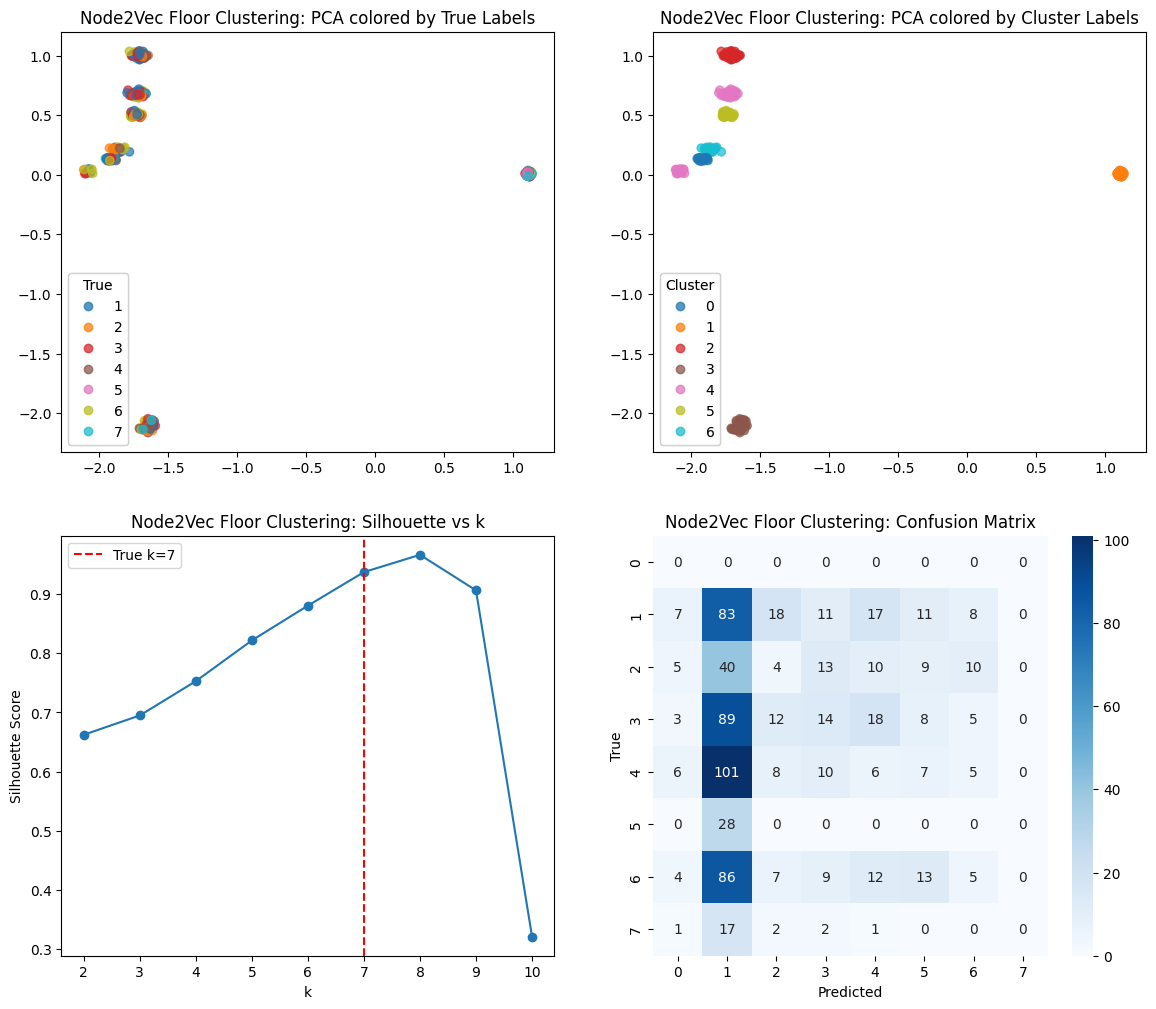

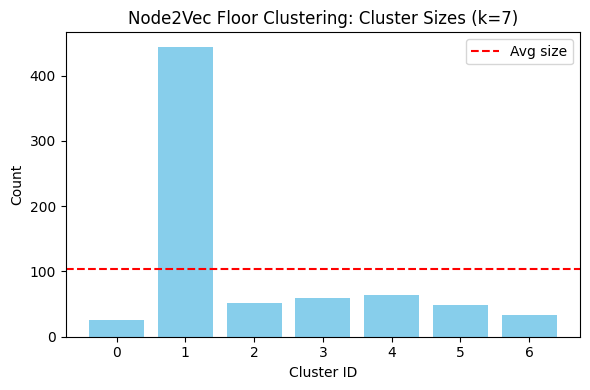

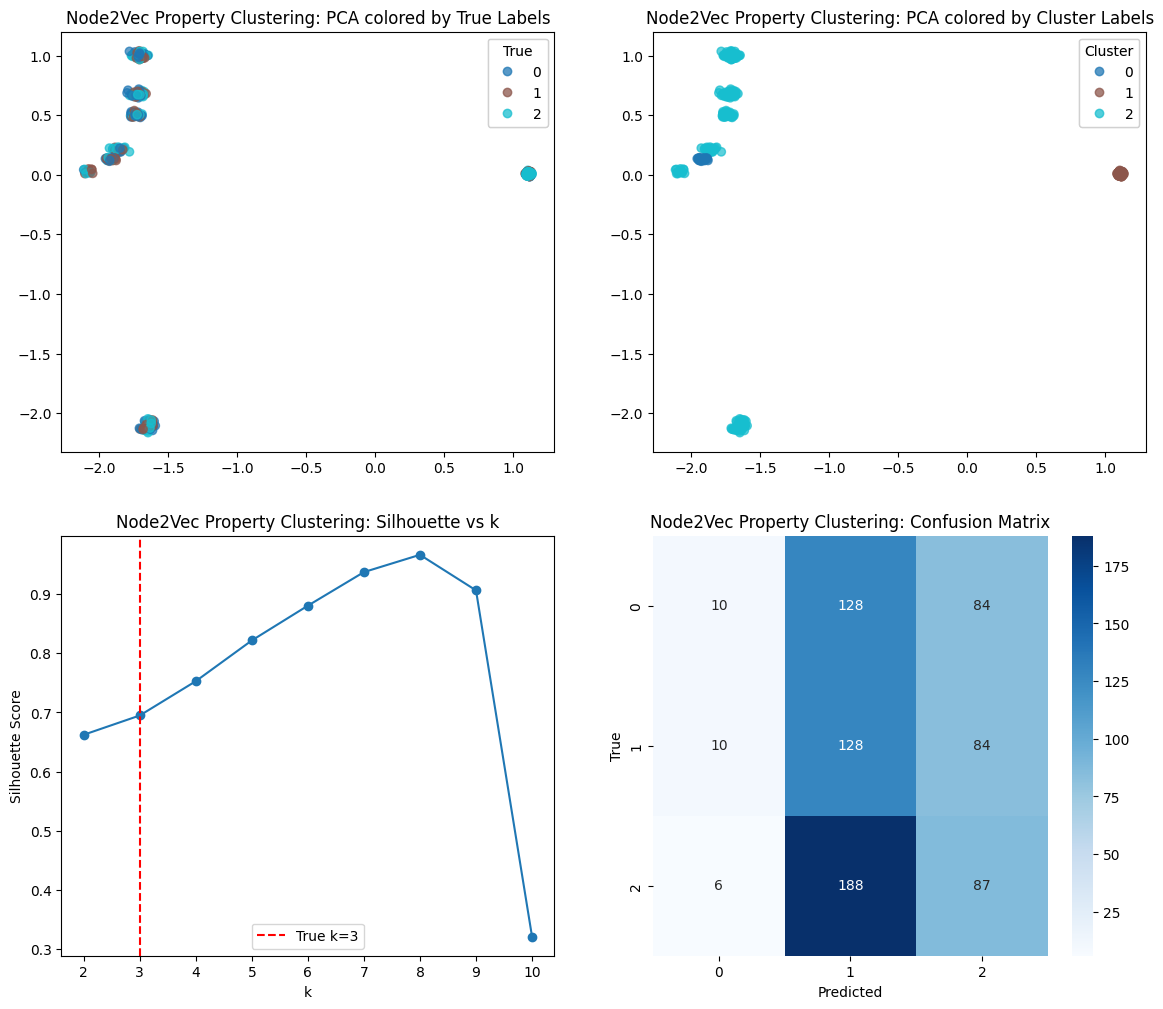

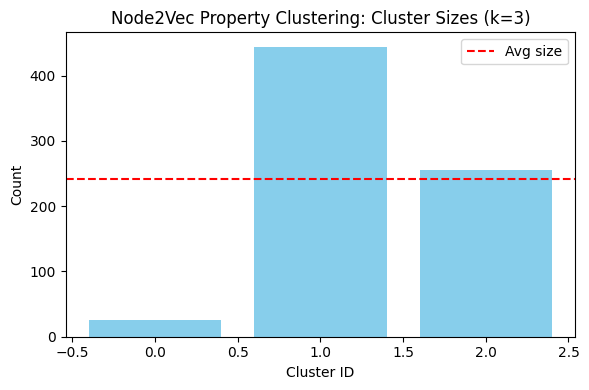

In [ ]:
#Usinfg visualization function
visualize_clusters(
    name="Node2Vec Floor Clustering",
    X=nv_feats,
    true_labels=floor_labels,
    cluster_labels=pred_floor_nv,
    k_ground=n_floors
)
visualize_clusters(
    name="Node2Vec Property Clustering",
    X=nv_feats,
    true_labels=property_labels,
    cluster_labels=pred_prop_nv,
    k_ground=n_properties
)

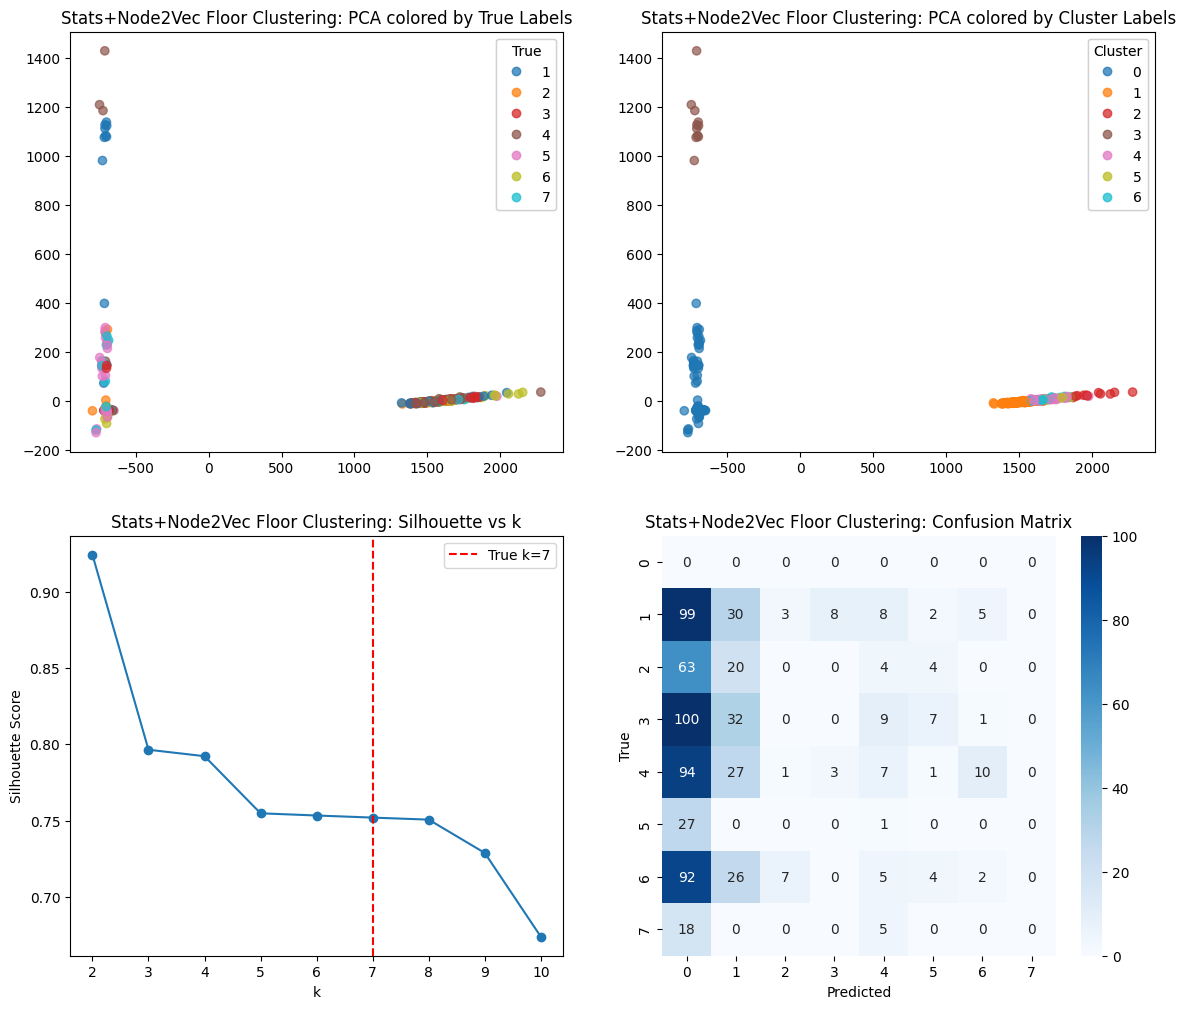

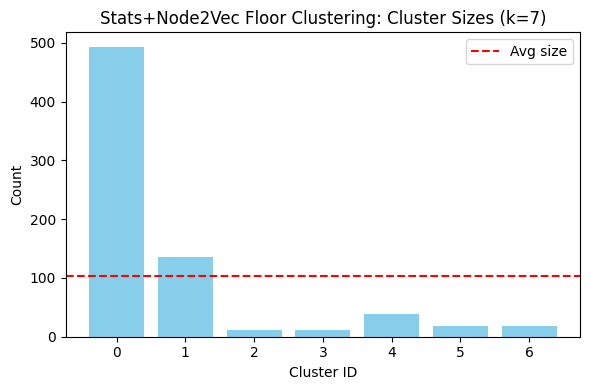

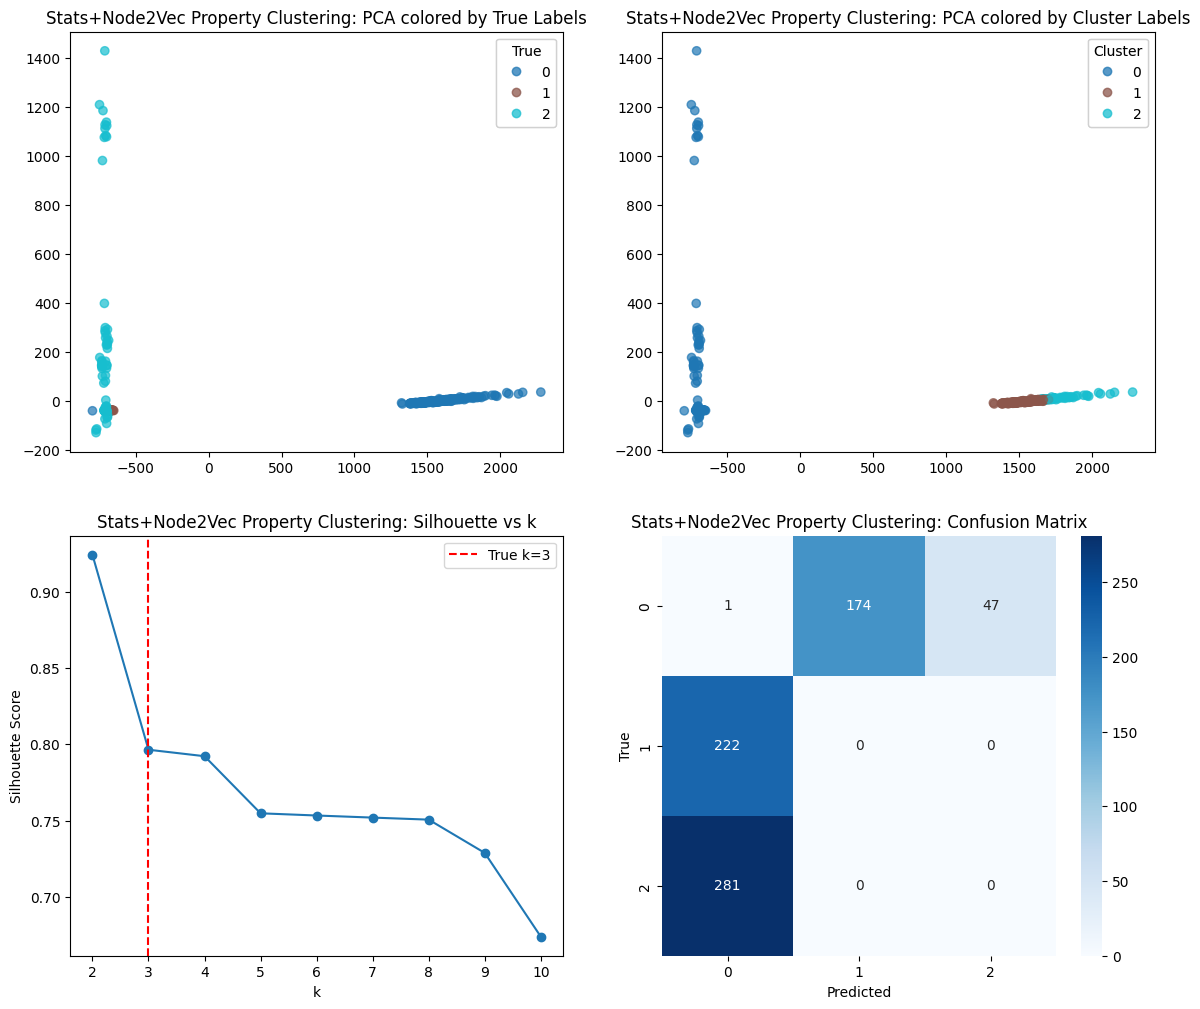

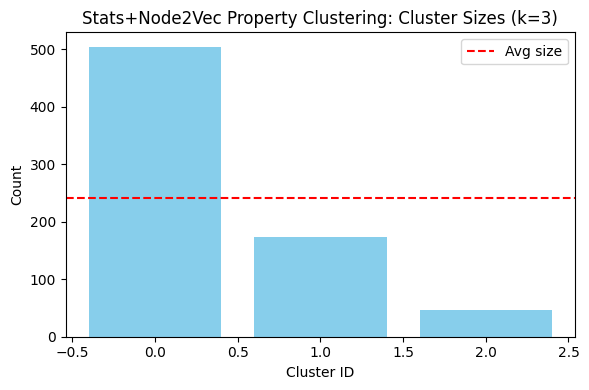

In [ ]:

visualize_clusters(
    name="Stats+Node2Vec Floor Clustering",
    X=fusion_feats,
    true_labels=floor_labels,
    cluster_labels=pred_floor_f,
    k_ground=n_floors
)
visualize_clusters(
    name="Stats+Node2Vec Property Clustering",
    X=fusion_feats,
    true_labels=property_labels,
    cluster_labels=pred_prop_f,
    k_ground=n_properties
)

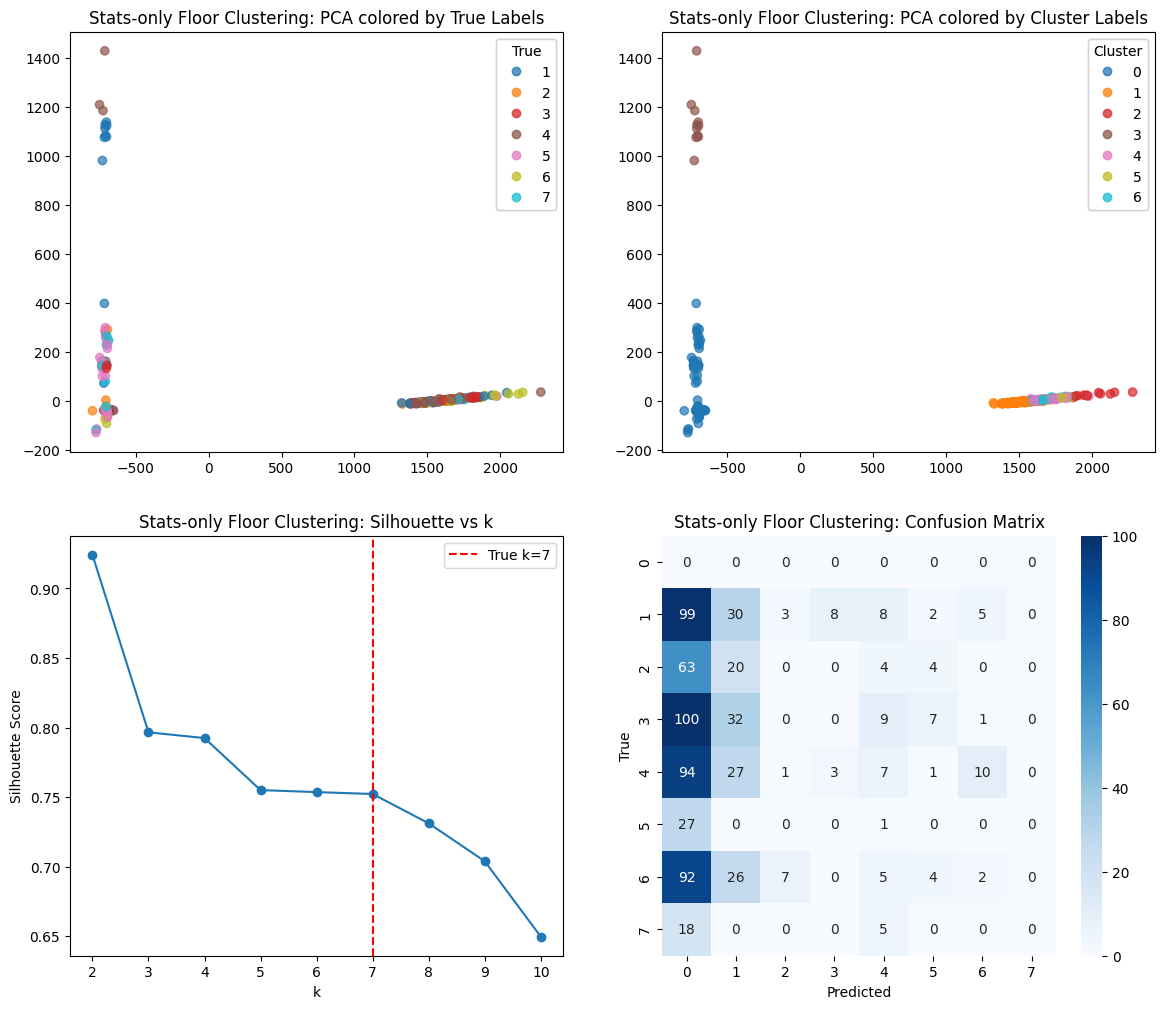

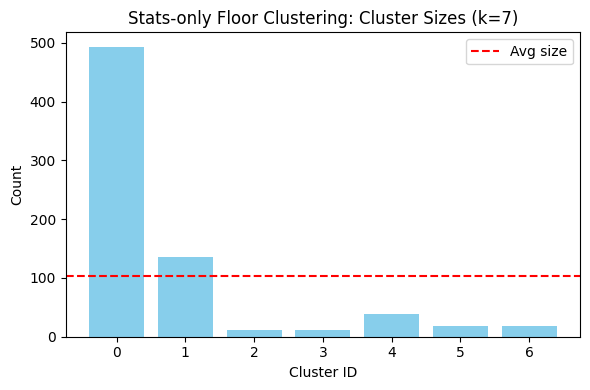

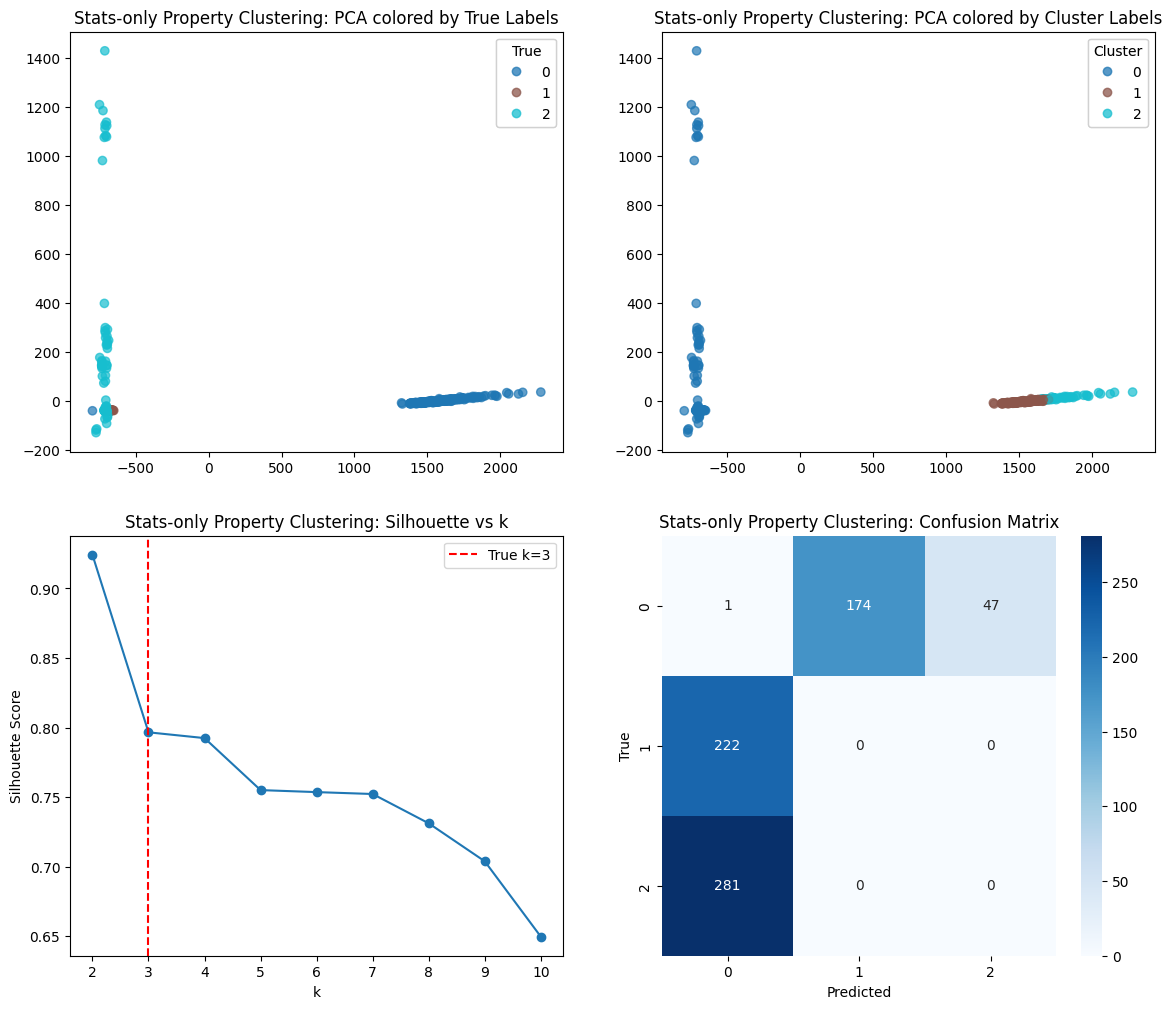

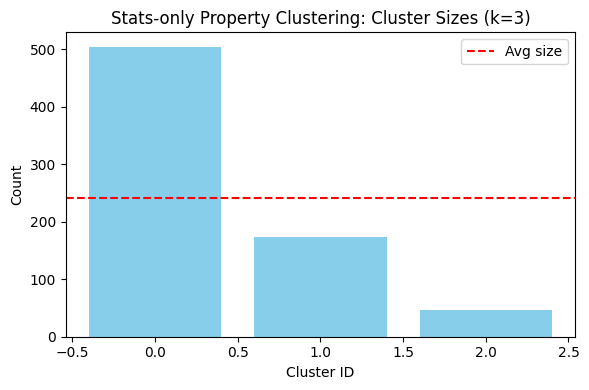

In [ ]:

visualize_clusters(
    name="Stats-only Floor Clustering",
    X=stats_feats,
    true_labels=floor_labels,
    cluster_labels=pred_floor,
    k_ground=n_floors
)
visualize_clusters(
    name="Stats-only Property Clustering",
    X=stats_feats,
    true_labels=property_labels,
    cluster_labels=pred_prop,
    k_ground=n_properties
)